# Customer Segmentation

## STEP 1:Introduction
Customer segmentation is the process of dividing customers into groups based on similar characteristics. This helps businesses understand customer behavior and improve marketing strategies.

## STEP 2: Problem Statement

Businesses often treat all customers the same, which reduces marketing efficiency. The goal of this project is to group customers based on spending behavior using machine learning.

## STEP 3: Dataset Description

The dataset contains customer details such as:

*Age

*Annual Income

*Spending Score

These values help identify customer purchasing patterns.

## STEP 4: Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## STEP 5: Load Dataset

In [2]:
df = pd.read_csv("C:\DATASCIENCE\DATASET\CSV\Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## STEP 6: Data Understanding
We observe customer income and spending score to understand buying behavior.

## STEP 7: Data Preprocessing

Unnecessary columns are removed and only numerical values are selected.

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


## STEP 8: Feature Selection 

Here, no target variable is used because clustering is unsupervised.

## STEP 9: Elbow Method 

Used to find optimal number of clusters.

C:\Users\shemin ts\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shemin ts\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shemin ts\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shemin ts\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memor

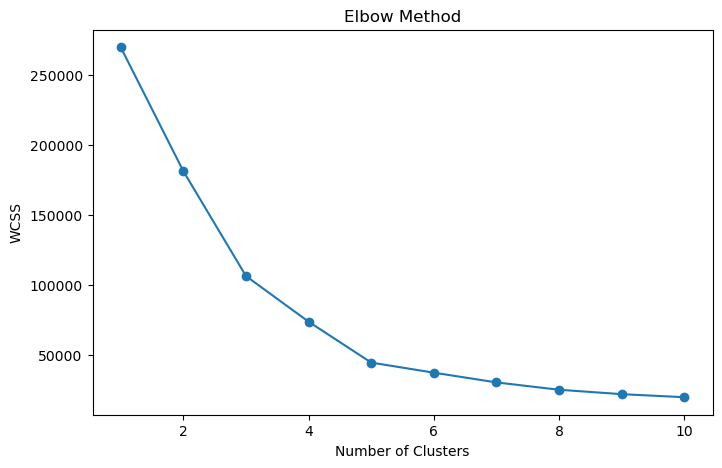

In [20]:
wcss = []  # Within-Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



## STEP 10: Model Training

In [ ]:
#Choose the number of clusters
n_clusters = 4

In [21]:
#Create and fit the KMeans model
from sklearn.cluster import KMeans

# Initialize KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Train the model (fit on features X)
kmeans.fit(X)


C:\Users\shemin ts\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, n_init=10, random_state=42)

In [22]:
#Assign cluster labels to each customer

# Add the predicted cluster for each customer to the DataFrame
df['Cluster'] = kmeans.labels_

# Check first few rows
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,3
2,3,Female,20,16,6,0
3,4,Female,23,16,77,3
4,5,Female,31,17,40,0


In [23]:
#Check cluster centers

# Each row = cluster center coordinates (Annual Income, Spending Score)
centers = kmeans.cluster_centers_
print("Cluster centers (Annual Income, Spending Score):")
print(centers)


Cluster centers (Annual Income, Spending Score):
[[26.30434783 20.91304348]
 [86.53846154 82.12820513]
 [87.         18.63157895]
 [48.26       56.48      ]]


## STEP 12: Result Interpretation

Customers are grouped into 5 segments based on income and spending habits.

In [24]:
import pandas as pd

centers = pd.DataFrame(kmeans.cluster_centers_, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centers

,Annual Income (k$),Spending Score (1-100)
0,26.304348,20.913043
1,86.538462,82.128205
2,87.000000,18.631579
3,48.260000,56.480000


### Assign descriptive labels

##### Based on income and spending score, you can describe clusters like this:

#### Cluster	-     Interpretation

0	-    Low Income, High Spenders

1	-   High Income, High Spenders

2	-    High Income, Low Spenders

3	-    Low Income, Low Spenders

*High Spending Score → customers spend a lot

*Low Spending Score → customers spend less

*High Income → earn more

*Low Income → earn less


In [25]:
#Check how many customers in each cluster
df['Cluster'].value_counts()

3    100
1     39
2     38
0     23
Name: Cluster, dtype: int64

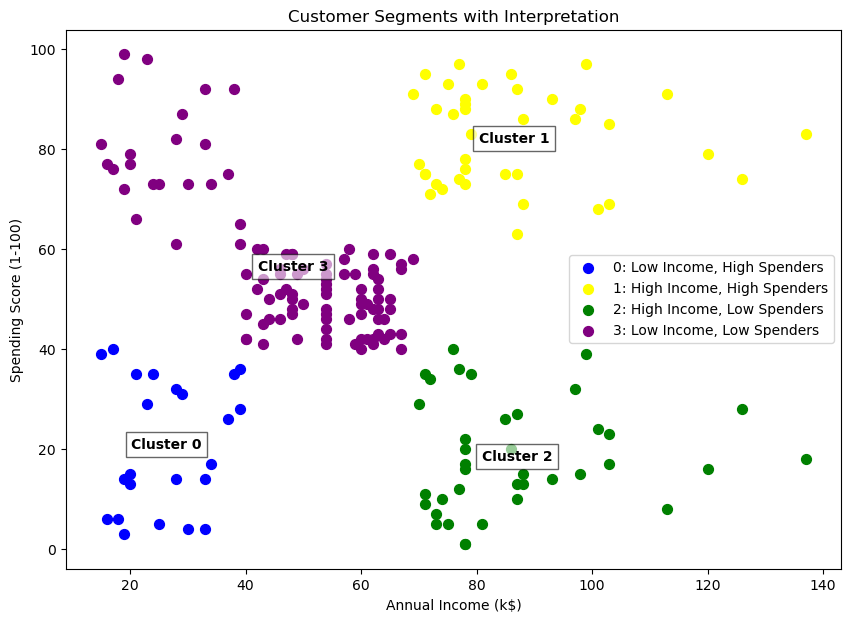

In [26]:
#Visualize for easy understanding
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
colors = ['blue', 'yellow', 'green', 'purple']

for i in range(4):
    plt.scatter(
        X[df['Cluster']==i].iloc[:,0],
        X[df['Cluster']==i].iloc[:,1],
        s=50,
        c=colors[i],
        label=f"{i}: {['Low Income, High Spenders','High Income, High Spenders','High Income, Low Spenders','Low Income, Low Spenders'][i]}"
    )

# Add cluster centers
for i, center in enumerate(kmeans.cluster_centers_):
    plt.text(center[0], center[1], f'Cluster {i}', horizontalalignment='center', verticalalignment='center', 
             fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black'))

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments with Interpretation")
plt.legend()
plt.show()


## STEP 13: Conclusion

Customer segmentation using KMeans clustering helped divide mall customers into distinct groups based on their Annual Income and Spending Score. Four main clusters were identified:

1.Low Income, High Spenders – Small earners who spend more than expected; good targets for affordable promotions.

2.High Income, High Spenders – Wealthy and active buyers; ideal for premium products and exclusive offers.

3.High Income, Low Spenders – Rich but cautious; loyalty programs can encourage more spending.

4.Low Income, Low Spenders – Budget-conscious customers; suitable for discounts or basic products.

This segmentation helps the mall understand customer behavior, improve marketing strategies, and make better business decisions by offering products and promotions tailored to each group.